# Weird AI Text Exploration

In this notebook we will:

- Load the Weird AI lyric corpus
- Explore the structure of the dataset
- Analyze word and character frequencies
- Identify repeated patterns in lyrics
- Prepare for tokenization

This notebook supports Lesson 1 of the Weird AI project.

In [1]:
from pathlib import Path

text = Path("../data/processed/lyrics_sample.txt").read_text(
    encoding="utf-8"
)

print(text[:4000])

[Intro]
"Look, I was gonna go easy on you not to hurt your feelings"
"But I'm only going to get this one chance" (Six minutes— Six minutes—)
"Something's wrong, I can feel it" (Six minutes, Slim Shady, you're on!)
"Just a feeling I've got, like something's about to happen, but I don't know what. 
If that means what I think it means, we're in trouble, big trouble; 
And if he is as bananas as you say, I'm not taking any chances"
"You are just what the doc ordered"

[Chorus]
I'm beginnin' to feel like a Rap God, Rap God
All my people from the front to the back nod, back nod
Now, who thinks their arms are long enough to slap box, slap box?
They said I rap like a robot, so call me Rap-bot

[Verse 1]
But for me to rap like a computer it must be in my genes
I got a laptop in my back pocket
My pen'll go off when I half-cock it
Got a fat knot from that rap profit
Made a livin' and a killin' off it
Ever since Bill Clinton was still in office
With Monica Lewinsky feelin' on his nutsack
I'm an MC 

In [2]:
character_count = len(text)

print(f"Characters in corpus: {character_count:,}")

lines = [
    line.strip()
    for line in text.splitlines()
    if line.strip()
]

print(f"Non-empty lines: {len(lines):,}")

Characters in corpus: 13,507,739
Non-empty lines: 373,467


In [3]:
average_line_length = sum(len(line) for line in lines) / len(lines)

print(f"Average line length: {average_line_length:.2f}")

Average line length: 35.07


In [4]:
from collections import Counter

words = text.lower().split()

word_counts = Counter(words)

# This is extremely important in an LLM
print(word_counts.most_common(20))

[('i', 95488), ('the', 84122), ('you', 73605), ('a', 50835), ('and', 44645), ('to', 43810), ('my', 41338), ('me', 33051), ('in', 30415), ('it', 30265), ("i'm", 30197), ('that', 26048), ('on', 24994), ('like', 21221), ('your', 19917), ('of', 18239), ('with', 17744), ("don't", 17080), ('we', 16372), ('all', 16165)]


In [5]:
character_counts = Counter(text)

# Begins to show how letters/words can be represented as numbers for the AI
print(character_counts.most_common(20))

[(' ', 2247856), ('e', 1089234), ('o', 854955), ('t', 836622), ('a', 719112), ('n', 660761), ('i', 592176), ('h', 561602), ('s', 512311), ('r', 460011), ('\n', 410457), ('l', 409191), ('u', 378056), ('y', 327898), ('d', 319246), ('m', 299182), ('g', 243510), (',', 236858), ('w', 219597), ('c', 202905)]


In [6]:
unique_words = set(words)

print(f"Unique words: {len(unique_words):,}")

Unique words: 85,187


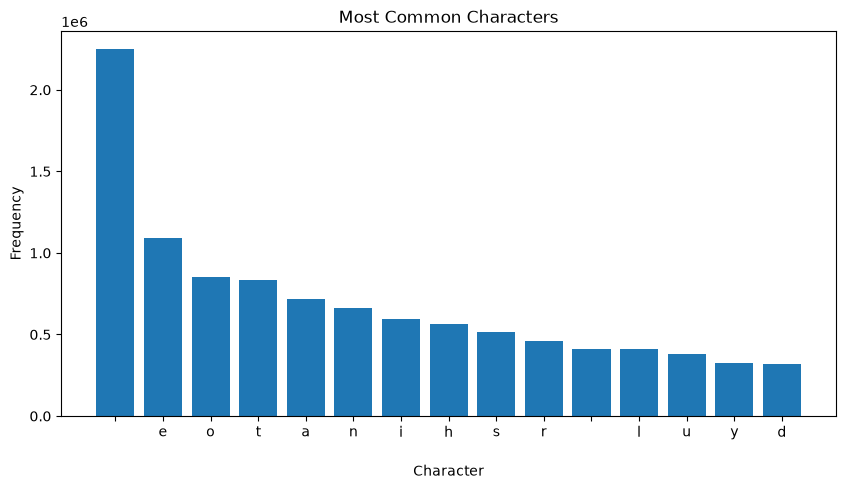

In [7]:
import matplotlib.pyplot as plt

most_common = character_counts.most_common(15)

characters = [item[0] for item in most_common]
counts = [item[1] for item in most_common]

plt.figure(figsize=(10, 5))
plt.bar(characters, counts)

plt.title("Most Common Characters")
plt.xlabel("Character")
plt.ylabel("Frequency")

plt.show()

## Reflection Questions

1. Why do spaces appear so frequently?
You would need for a specific letter to appear in every single word and occasionally multiple times just to occur
more often than spaces do.
2. Why are some words dramatically more common than others?
Words are not evenly distributed throughout songs. Words like I, me, and the appear super frequently because most songs have 
a subject and those are common subjects of songs.
3. Why might punctuation matter in song lyrics?
It can inform you of the rhythm of a song, the cadence can be defined through punctuation and capitalization.
4. What challenges might this dataset create for an AI model?
The distribution of the data, there is likely some kind of bias around what songs are included in the dataset.
5. What kinds of bias might exist in lyric datasets?
Genres choices are biased, creators could be chosen with a bias or based on popularity.